# Dashboard de Calidad de Datos (Data Quality)

Este notebook amplía el análisis de `data_quality.py` para proporcionar visualizaciones de diagnóstico sobre la integridad, validez y consistencia del dataset unificado de clima.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

INPUT_PARQUET = "clima_unificado.parquet"

## 0. Carga de Datos

In [2]:
if os.path.exists(INPUT_PARQUET):
    df = pd.read_parquet(INPUT_PARQUET)
    print(f"Dataset cargado: {len(df)} filas y {len(df.columns)} columnas.")
    display(df.head())
else:
    print(f"Error: No se encontró {INPUT_PARQUET}.")

Dataset cargado: 33812 filas y 26 columnas.


,station_id,obs_timestamp,temp_real,dew_real,hum_real,wind_speed_real,wind_gust_real,wind_dir_real,press_real,sea_level_press_real,...,fcst_start,fcst_end,is_daytime_fcst,temp_fcst,dew_fcst,hum_fcst,wind_speed_fcst,wind_dir_fcst,precip_prob_fcst,short_fcst
0,KIND,2026-04-10 11:00:00+00:00,16.0,6.0,51.478580,18.504,NaN,210.0,102133.48,NaN,...,2026-04-10 11:00:00+00:00,2026-04-10 12:00:00+00:00,True,63.0,6.666667,51.0,10 mph,SSW,12.0,Partly Sunny
1,KEYE,2026-04-10 11:00:00+00:00,16.0,6.0,51.478580,12.960,NaN,200.0,102133.48,NaN,...,2026-04-10 11:00:00+00:00,2026-04-10 12:00:00+00:00,True,63.0,6.666667,51.0,10 mph,SSW,12.0,Partly Sunny
2,KGEZ,2026-04-10 11:00:00+00:00,13.0,6.0,62.484658,18.504,NaN,190.0,102201.21,NaN,...,2026-04-10 11:00:00+00:00,2026-04-10 12:00:00+00:00,True,63.0,6.666667,51.0,10 mph,SSW,12.0,Partly Sunny
3,KBMG,2026-04-10 11:00:00+00:00,18.0,6.0,45.352703,NaN,35.172,NaN,102268.94,NaN,...,2026-04-10 11:00:00+00:00,2026-04-10 12:00:00+00:00,True,63.0,6.666667,51.0,10 mph,SSW,12.0,Partly Sunny
4,KMIE,2026-04-10 11:00:00+00:00,16.0,5.0,48.029753,18.504,NaN,210.0,NaN,NaN,...,2026-04-10 11:00:00+00:00,2026-04-10 12:00:00+00:00,True,63.0,6.666667,51.0,10 mph,SSW,12.0,Partly Sunny


## 1. INTEGRIDAD (Completitud)

¿Qué tan completo es nuestro dataset? Visualizamos los valores nulos por columna.

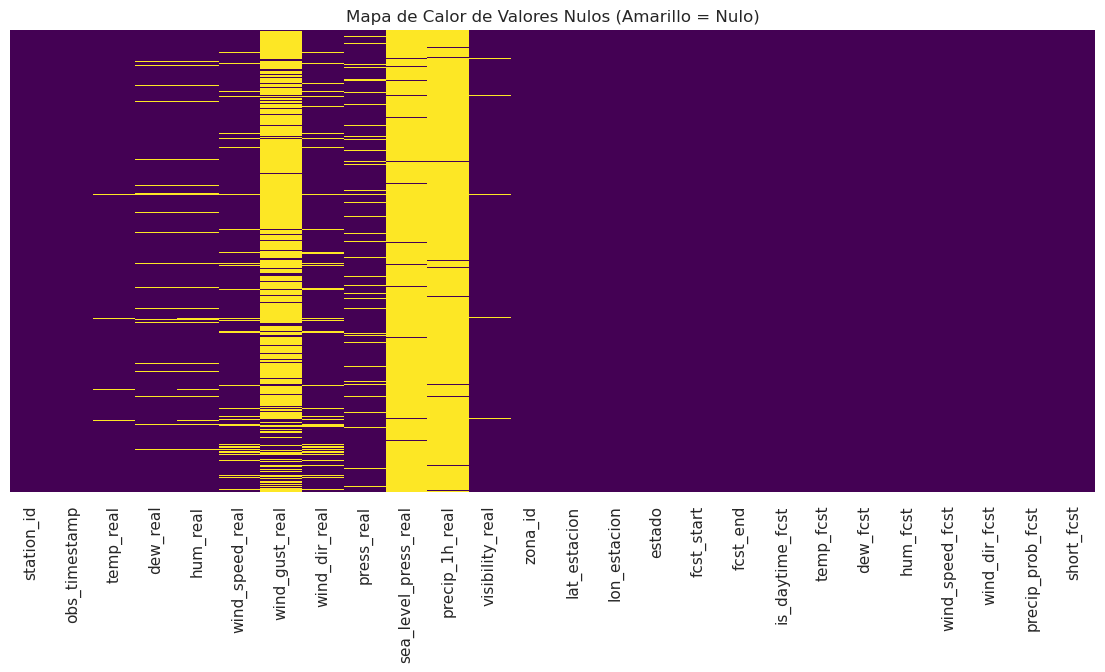

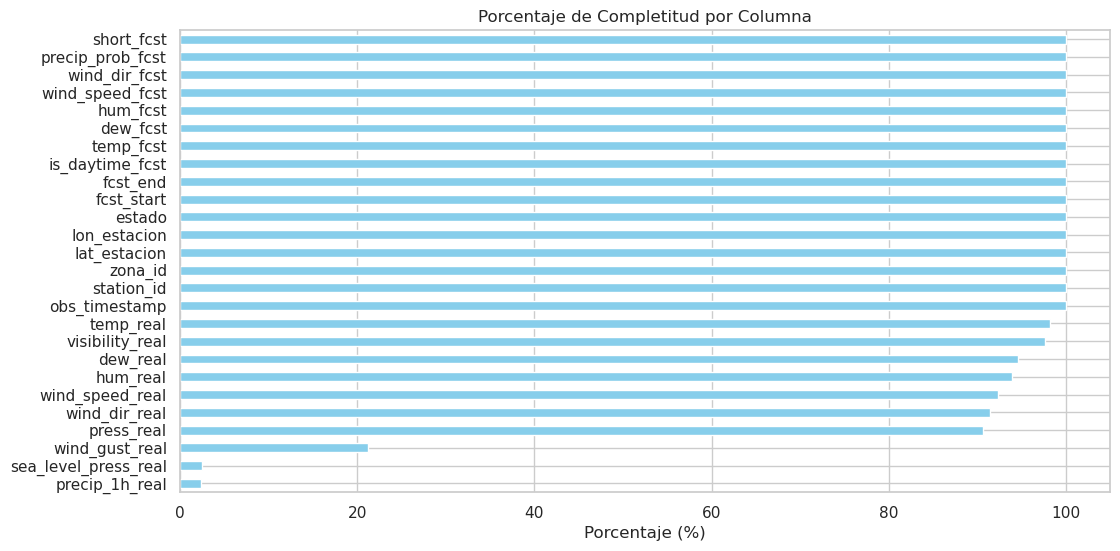

In [3]:
# Mapa de calor de nulos
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Amarillo = Nulo)')
plt.show()

# Porcentaje de completitud
integrity = (df.notnull().sum() / len(df) * 100).sort_values()
integrity.plot(kind='barh', color='skyblue')
plt.title('Porcentaje de Completitud por Columna')
plt.xlabel('Porcentaje (%)')
plt.show()

### Observaciones:

1. windGust (Ráfagas)
   
   * Umbral Crítico: Las estaciones automáticas (como las ASOS/AWOS en aeropuertos) están programadas para reportar windGust solo si la velocidad máxima supera la velocidad sostenida por al menos 10-15 nudos.
   * Interpretación: Si el campo es null, es altamente probable que el viento fuera estable o muy débil. No es necesariamente una falla del sensor, sino una ausencia de evento significativo.

2. seaLevelPressure (Presión al Nivel del Mar)
   * Sensor Específico: Requiere un barómetro de alta precisión y una calibración constante basada en la elevación de la estación. 
   * Disponibilidad: Muchas estaciones de la red no reportan este valor porque no tienen el  hardware para el cálculo de presion al nivel del mar. Solo reportan la presión de la estación (barometricPressure).
   * Interpretación: Es una limitación de hardware de la estación emisora.

3. precipitationLastHour (Precipitación)
   * Ausencia de lluvia vs. Ausencia de sensor: En muchos endpoints de NOAA, un null significa "no se detectó lluvia", pero en otros significa "no hay sensor". 
   * Interpretación: Es la variable más "ruidosa". Se recomienda tratar el null como 0.0 solo si la estación tiene historial de haber reportado lluvia en el pasado, lo que confirma que tiene el sensor.


## 2. UNICIDAD

Buscamos duplicados basados en la llave natural: `station_id` + `obs_timestamp`.

In [4]:
duplicates = df.duplicated(subset=['station_id', 'obs_timestamp']).sum()
print(f"Filas duplicadas: {duplicates}")
print(f"Índice de Unicidad: {(1 - (duplicates / len(df))) * 100:.2f}%")

if duplicates > 0:
    print("Muestra de duplicados:")
    display(df[df.duplicated(subset=['station_id', 'obs_timestamp'], keep=False)].sort_values(by=['station_id', 'obs_timestamp']).head())

Filas duplicadas: 17
Índice de Unicidad: 99.95%
Muestra de duplicados:


,station_id,obs_timestamp,temp_real,dew_real,hum_real,wind_speed_real,wind_gust_real,wind_dir_real,press_real,sea_level_press_real,...,fcst_start,fcst_end,is_daytime_fcst,temp_fcst,dew_fcst,hum_fcst,wind_speed_fcst,wind_dir_fcst,precip_prob_fcst,short_fcst
8211,KAGO,2026-04-11 01:35:00+00:00,NaN,16.0,NaN,0.000,NaN,0.0,102235.08,NaN,...,2026-04-11 01:00:00+00:00,2026-04-11 02:00:00+00:00,False,76.0,14.444444,54.0,5 mph,SE,5.0,Mostly Clear
8287,KAGO,2026-04-11 01:35:00+00:00,19.0,16.0,82.752266,0.000,NaN,0.0,102235.08,NaN,...,2026-04-11 01:00:00+00:00,2026-04-11 02:00:00+00:00,False,76.0,14.444444,54.0,5 mph,SE,5.0,Mostly Clear
32220,KBIX,2026-04-12 21:55:00+00:00,24.8,18.2,66.761037,18.504,NaN,150.0,102302.80,102330.0,...,2026-04-12 21:00:00+00:00,2026-04-12 22:00:00+00:00,True,81.0,17.222222,54.0,15 mph,SE,0.0,Sunny
32223,KBIX,2026-04-12 21:55:00+00:00,24.8,18.2,66.761037,18.360,NaN,150.0,102300.00,102330.0,...,2026-04-12 21:00:00+00:00,2026-04-12 22:00:00+00:00,True,81.0,17.222222,54.0,15 mph,SE,0.0,Sunny
21013,KBTN,2026-04-12 01:35:00+00:00,8.0,8.0,100.000000,NaN,NaN,NaN,100440.29,NaN,...,2026-04-12 01:00:00+00:00,2026-04-12 02:00:00+00:00,False,73.0,11.111111,48.0,15 mph,SE,8.0,Mostly Clear


### Observaciones:

Dos situaciones posibles que afectan a la unicidad:

- Reporte Parcial (ej: KAGO filas 8211 y 8287): Mismo timestamp pero distintos valores (uno null y uno non-null). Esto sugiere que el reporte original se actualizó posteriormente, lo que es común en estaciones automáticas que refinan sus datos después de la observación inicial.

- Correcciones (ej: KBIX filas 32220 yy 32223): Mismo timestamp, valores ligeramente distintos.En meteorología, esto se conoce como una Corrección (METAR COR). La estación detecta un error de sensor o de transmisión y re-envía el dato corregido para el mismo minuto exacto.

Opciones: Conservar registro mas completo y/o ultimo registro.

## 3. VALIDEZ (Outliers y Reglas de Negocio)

Validamos que las variables físicas estén dentro de rangos coherentes.

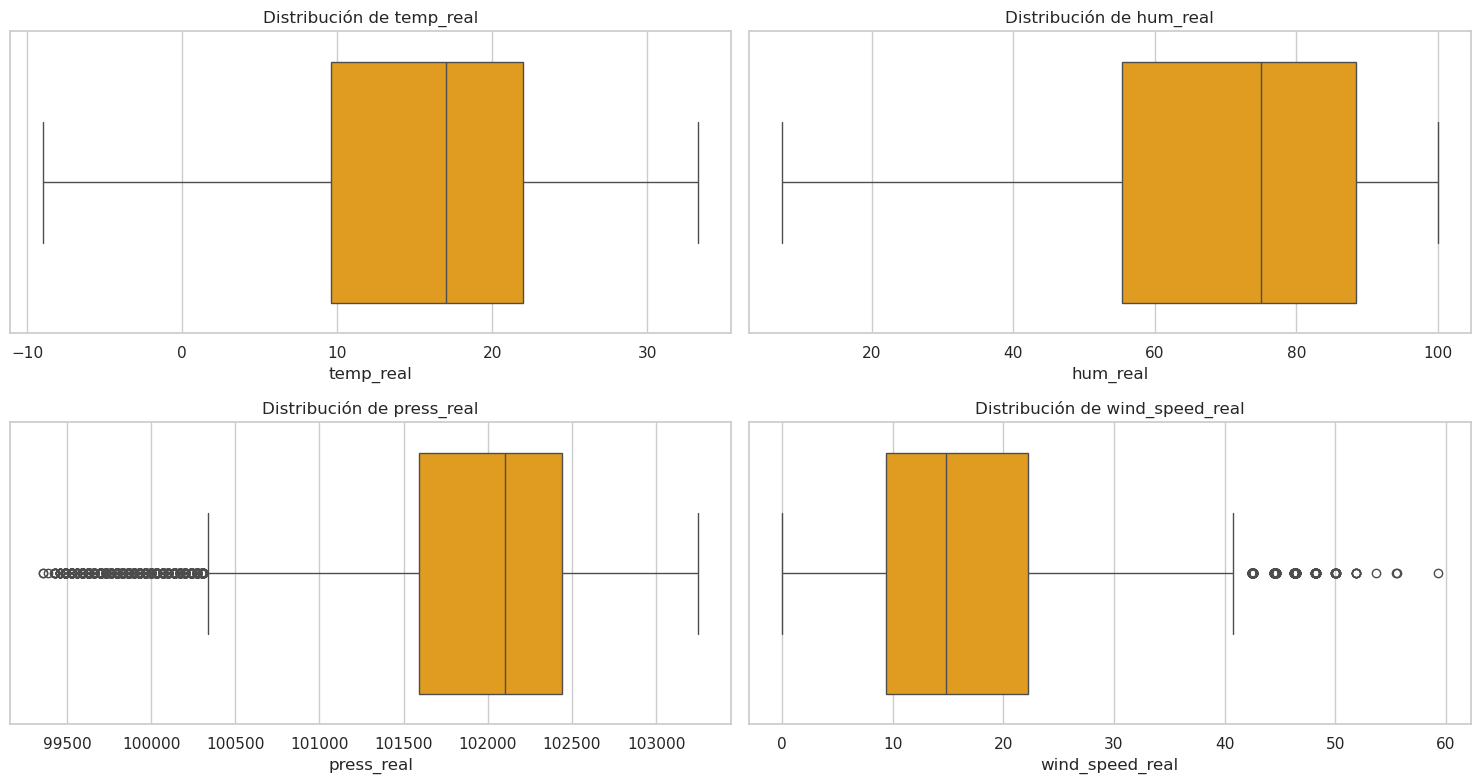

In [5]:
cols_to_check = ['temp_real', 'hum_real', 'press_real', 'wind_speed_real']

plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_check, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[col], color='orange')
        plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

## 4. OPORTUNIDAD (Línea de Tiempo)

Analizamos la cobertura temporal del dataset por zona.

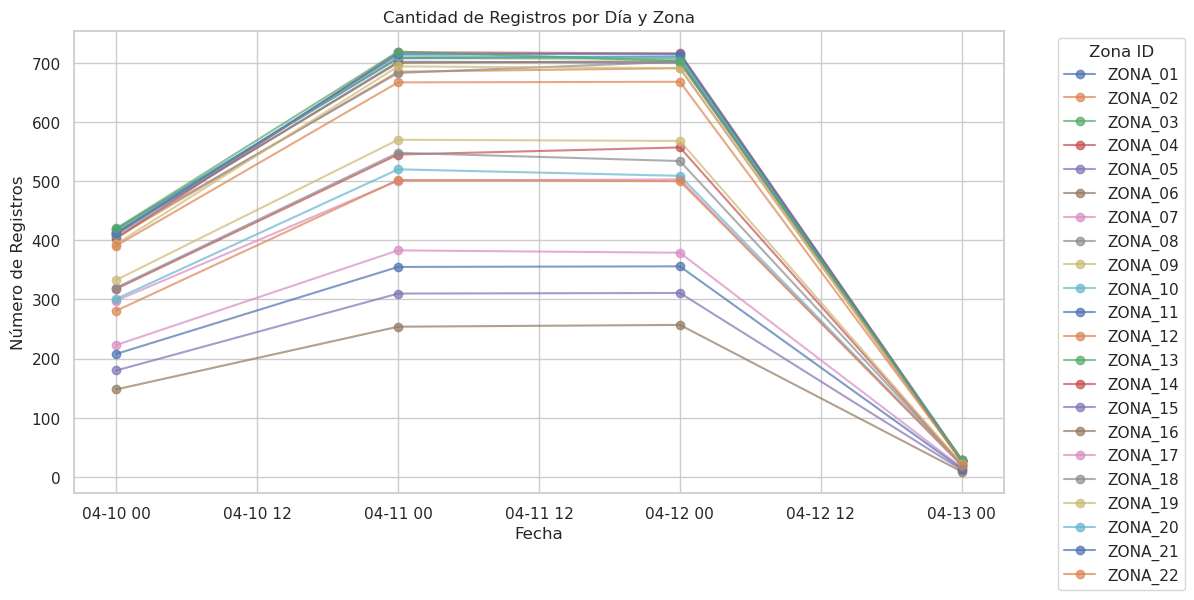

In [6]:
df['fecha'] = df['obs_timestamp'].dt.date
timeline = df.groupby(['fecha', 'zona_id']).size().unstack(fill_value=0)

timeline.plot(marker='o', alpha=0.7)
plt.title('Cantidad de Registros por Día y Zona')
plt.ylabel('Número de Registros')
plt.xlabel('Fecha')
plt.legend(title='Zona ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. CONSISTENCIA (Real vs Pronóstico)

Comparamos la temperatura real contra el forecast de NOAA.

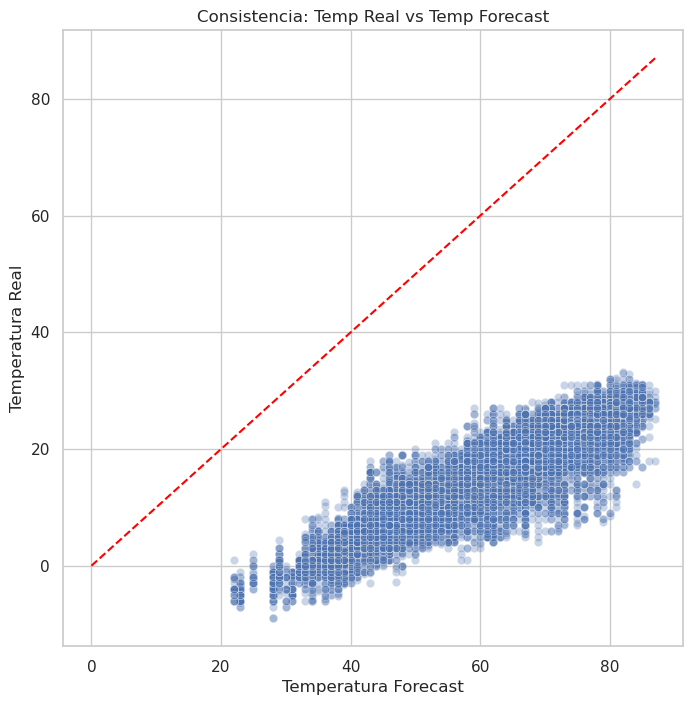

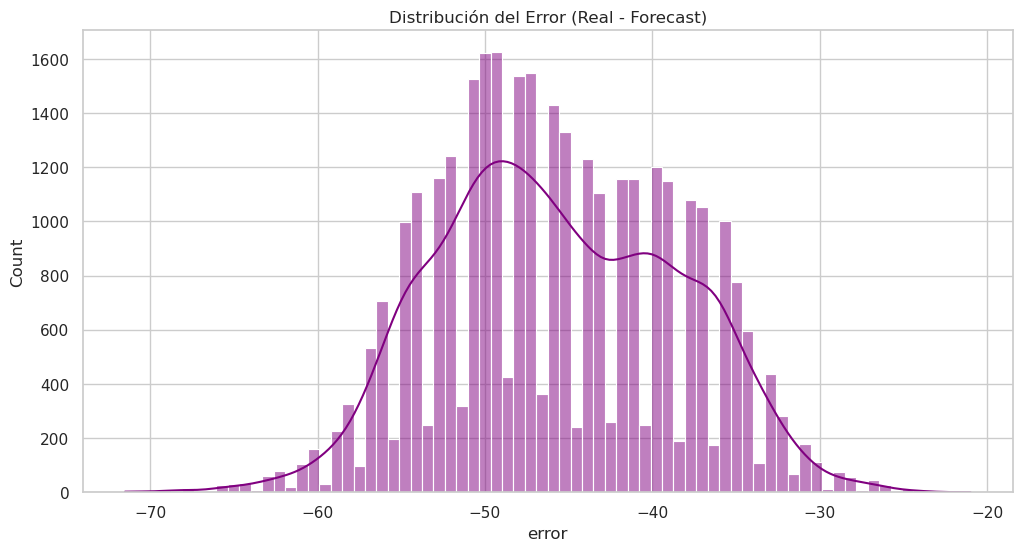

In [7]:
if 'temp_real' in df.columns and 'temp_fcst' in df.columns:
    plt.figure(figsize=(8, 8))
    # Limpiamos nulos para el scatter plot
    aligned = df.dropna(subset=['temp_real', 'temp_fcst'])
    
    sns.scatterplot(data=aligned, x='temp_fcst', y='temp_real', alpha=0.3)
    # Línea ideal (x=y)
    limit = max(aligned['temp_real'].max(), aligned['temp_fcst'].max())
    plt.plot([0, limit], [0, limit], color='red', linestyle='--')

    plt.title('Consistencia: Temp Real vs Temp Forecast')
    plt.xlabel('Temperatura Forecast')
    plt.ylabel('Temperatura Real')
    plt.show()
    
    # Distribución del Error
    aligned['error'] = aligned['temp_real'] - aligned['temp_fcst']
    sns.histplot(aligned['error'], kde=True, color='purple')
    plt.title('Distribución del Error (Real - Forecast)')
    plt.show()

## 6. IDONEIDAD (Estaciones y Cobertura)

¿Cuántos datos aporta cada estación?

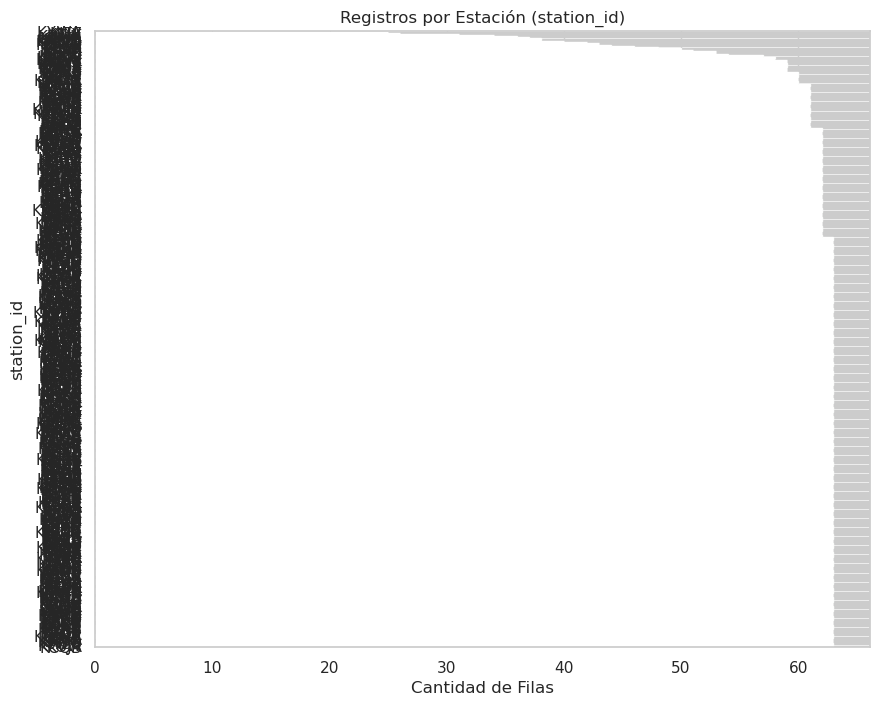

In [8]:
plt.figure(figsize=(10, 8))
df['station_id'].value_counts().plot(kind='barh', color='green')
plt.title('Registros por Estación (station_id)')
plt.xlabel('Cantidad de Filas')
plt.show()